# SaaS Churn Drivers

Product question: which account signals should the retention team prioritize before a customer leaves?
Simulated SaaS account table with tenure, monthly charges, total charges, support tickets, and churn labels.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
df_churn = pd.read_csv('../data/churn_data.csv')
df_churn.head()


,customerID,tenure,MonthlyCharges,TotalCharges,SupportTickets,Churn
0,C00000,54,71.25,3871.44,3,0
1,C00001,56,31.28,1744.16,2,0
2,C00002,22,15.00,327.23,1,0
3,C00003,65,84.53,5493.83,3,0
4,C00004,22,52.04,1134.18,2,1


In [ ]:
df_churn.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      2500 non-null   object 
 1   tenure          2500 non-null   int64  
 2   MonthlyCharges  2500 non-null   float64
 3   TotalCharges    2473 non-null   float64
 4   SupportTickets  2500 non-null   int64  
 5   Churn           2500 non-null   int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 117.3+ KB


In [ ]:
df_churn.isnull().sum()


customerID         0
tenure             0
MonthlyCharges     0
TotalCharges      27
SupportTickets     0
Churn              0
dtype: int64

In [ ]:
df_churn[df_churn['TotalCharges'].isnull()].head(10)


,customerID,tenure,MonthlyCharges,TotalCharges,SupportTickets,Churn
9,C00009,0,44.65,NaN,2,1
38,C00038,0,56.51,NaN,3,1
96,C00096,0,64.76,NaN,1,0
418,C00418,0,37.40,NaN,2,1
605,C00605,0,48.73,NaN,4,1
736,C00736,0,84.19,NaN,4,1
764,C00764,0,55.45,NaN,1,1
860,C00860,0,63.85,NaN,3,1
919,C00919,0,77.91,NaN,1,1
953,C00953,0,22.58,NaN,1,1


In [ ]:
df_churn['TotalCharges'] = df_churn['TotalCharges'].fillna(0)
df_churn.shape


(2500, 6)

In [ ]:
df_churn['Churn'].value_counts(normalize=True).round(3)


Churn
0    0.672
1    0.328
Name: proportion, dtype: float64

Base churn is high enough for targeted retention work, but not so imbalanced that resampling is needed here.
Compare the main behavioral and billing features by churn status.

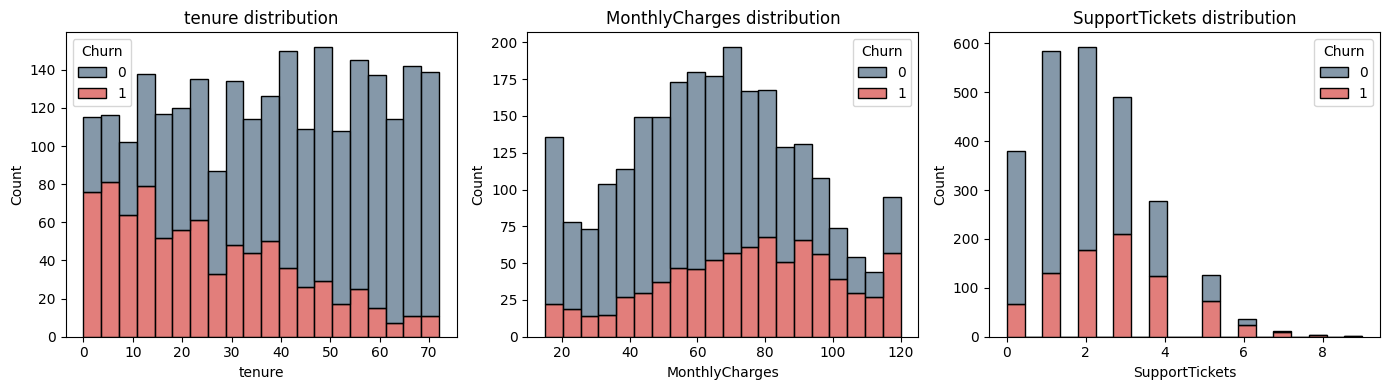

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features_list = ['tenure', 'MonthlyCharges', 'SupportTickets']
colors_palette = ['#5c768d', '#d9534f']
for i, col in enumerate(features_list):
    sns.histplot(data=df_churn, x=col, hue='Churn', ax=axes[i], bins=20, palette=colors_palette, multiple='stack')
    axes[i].set_title(f'{col} distribution')
plt.tight_layout()
plt.show()


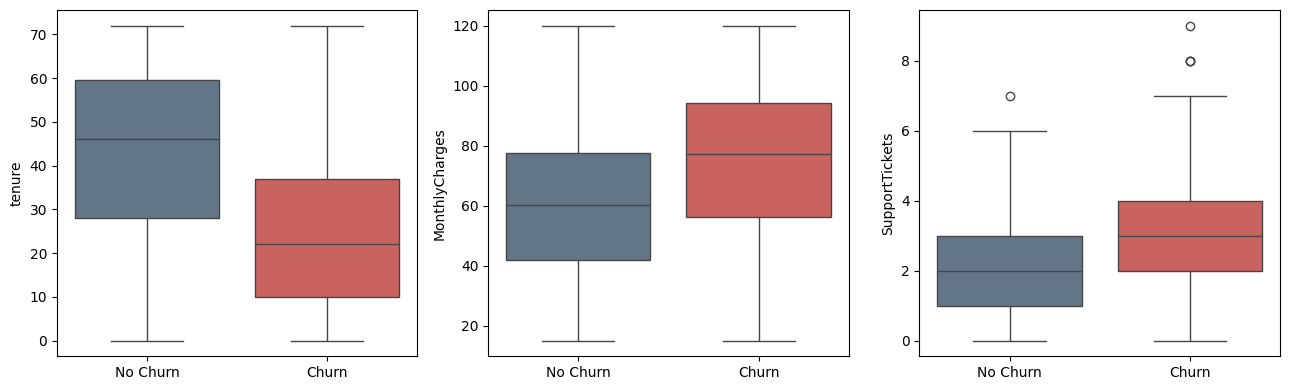

In [ ]:
df_churn['Churn_status'] = df_churn['Churn'].map({0: 'No Churn', 1: 'Churn'})
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(features_list):
    sns.boxplot(data=df_churn, x='Churn_status', y=col, ax=axes[i], hue='Churn_status', palette={'No Churn': '#5c768d', 'Churn': '#d9534f'}, legend=False)
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()


Check normality before choosing comparison tests.

In [ ]:
import scipy.stats as stats
for col in features_list:
    shapiro_stat, shapiro_p = stats.shapiro(df_churn[col].sample(400, random_state=7))
    print(f"{col:15s} stat={shapiro_stat:.4f} p-val={shapiro_p:.4f}")


tenure          stat=0.9515 p-val=0.0000
MonthlyCharges  stat=0.9818 p-val=0.0001
SupportTickets  stat=0.9332 p-val=0.0000


the feature distributions are not normal. use Mann-Whitney U for tenure/tickets and Welch's t-test for MonthlyCharges.

In [ ]:
churners = df_churn[df_churn['Churn'] == 1]['MonthlyCharges']
non_churners = df_churn[df_churn['Churn'] == 0]['MonthlyCharges']
t_stat, t_p = stats.ttest_ind(churners, non_churners, equal_var=False)
print(f"MonthlyCharges t-test p-val: {t_p:.4f}")


MonthlyCharges t-test p-val: 0.0000


In [ ]:
for col in ['tenure', 'SupportTickets']:
    stat, p_val = stats.mannwhitneyu(df_churn[df_churn['Churn']==1][col], df_churn[df_churn['Churn']==0][col])
    print(f"{col:15s} MWU p-val: {p_val:.4f}")


tenure          MWU p-val: 0.0000
SupportTickets  MWU p-val: 0.0000


Check multicollinearity before fitting the logistic model.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

feat_cols = df_churn[['tenure', 'MonthlyCharges', 'TotalCharges', 'SupportTickets']]
feat_with_const = sm.add_constant(feat_cols)
vif_df = pd.DataFrame()
vif_df['feature'] = feat_with_const.columns
vif_df['VIF'] = [variance_inflation_factor(feat_with_const.values, i) for i in range(feat_with_const.shape[1])]
print(vif_df[vif_df['feature'] != 'const'])


          feature        VIF
1          tenure   6.916280
2  MonthlyCharges   4.433779
3    TotalCharges  10.035125
4  SupportTickets   1.264512


TotalCharges has a high VIF because it is strongly tied to tenure and monthly charges, so it is removed from the final model.

In [ ]:
import statsmodels.api as sm
X_vars = df_churn[['tenure', 'MonthlyCharges', 'SupportTickets']]
X_matrix = sm.add_constant(X_vars)
y_target = df_churn['Churn']

logit_model = sm.Logit(y_target, X_matrix).fit()
logit_model.summary()


Optimization terminated successfully.
         Current function value: 0.483216
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 2500
Model:                          Logit   Df Residuals:                     2496
Method:                           MLE   Df Model:                            3
Date:                Sat, 20 Jun 2026   Pseudo R-squ.:                  0.2367
Time:                        01:43:14   Log-Likelihood:                -1208.0
converged:                       True   LL-Null:                       -1582.6
Covariance Type:            nonrobust   LLR p-value:                4.683e-162
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.8826      0.150     -5.872      0.000      -1.177      -0.588
tenure            -0.0548      0.003    -19.662      0.000      -0.060      -0.049
MonthlyCharges     0.0179      0.002      8.281      0.000       0.014       0.022
SupportTickets     0.3560      0.038      9.417      0.000       0.282       0.430
==================================================================================
"""

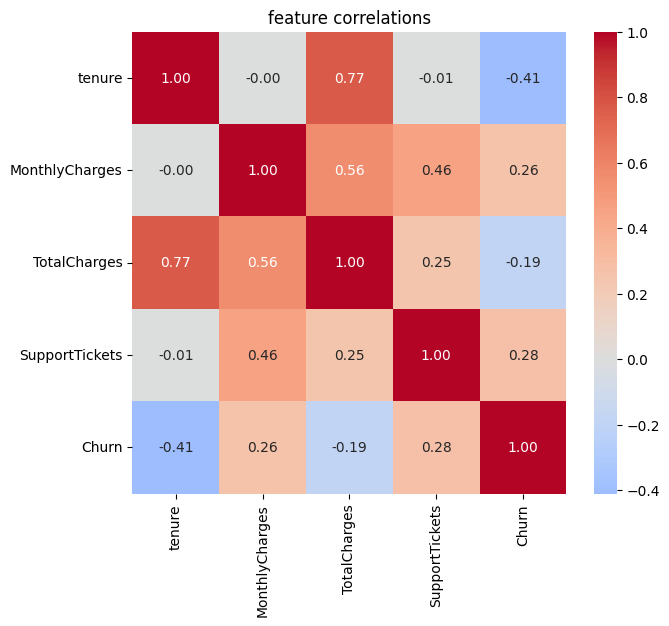

In [ ]:
plt.figure(figsize=(7, 6))
sns.heatmap(df_churn[['tenure', 'MonthlyCharges', 'TotalCharges', 'SupportTickets', 'Churn']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('feature correlations')
plt.show()


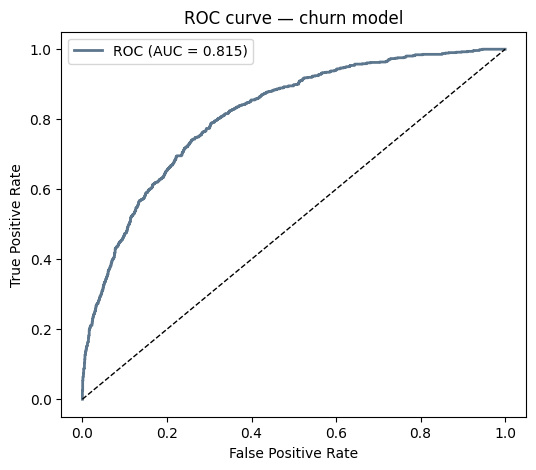

In [ ]:
pred_probs = logit_model.predict(X_matrix)

from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_target, pred_probs)
auc = roc_auc_score(y_target, pred_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#5c768d', lw=2, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve — churn model')
plt.legend()
plt.show()


### regression results explanation
all 3 predictors look significant (p < 0.05). 
- tenure goes up -> churn goes down (negative coefficient).
- support tickets go up -> churn goes up (positive coefficient).
- monthly charges small positive effect.
retention team should prioritize new users (< 6mo) with 2+ open tickets.
the AUC of the ROC curve tells us how well the model separates churners from non-churners (> 0.7 is decent).